In [21]:
import scipy.cluster.hierarchy as sch
val=[[2,5],[3,6],[7,10],[12,10],[6,3],[10,20]]
sch.linkage(val)

array([[ 0.        ,  1.        ,  1.41421356,  2.        ],
       [ 4.        ,  6.        ,  4.24264069,  3.        ],
       [ 2.        ,  3.        ,  5.        ,  2.        ],
       [ 7.        ,  8.        ,  5.65685425,  5.        ],
       [ 5.        ,  9.        , 10.19803903,  6.        ]])

In [37]:
val = np.array(val)
n = val.shape[0]
dist_matrix = np.zeros((n,n))
for i in range(n):
    for j in range(n):
        dist_matrix[i,j] = np.sqrt(np.sum((val[i] - val[j])**2))
print(dist_matrix)

[[ 0.          1.41421356  7.07106781 11.18033989  4.47213595 17.        ]
 [ 1.41421356  0.          5.65685425  9.8488578   4.24264069 15.65247584]
 [ 7.07106781  5.65685425  0.          5.          7.07106781 10.44030651]
 [11.18033989  9.8488578   5.          0.          9.21954446 10.19803903]
 [ 4.47213595  4.24264069  7.07106781  9.21954446  0.         17.4642492 ]
 [17.         15.65247584 10.44030651 10.19803903 17.4642492   0.        ]]


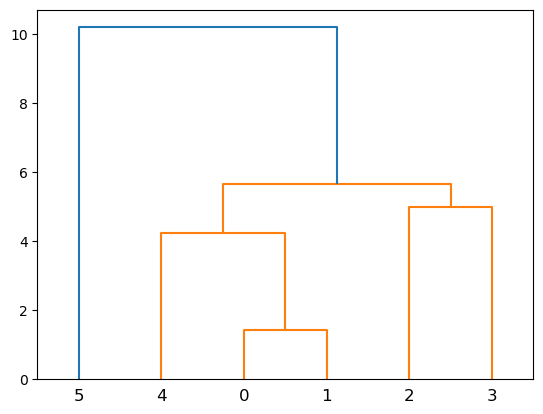

In [39]:
import matplotlib.pyplot as plt 
dendogram=sch.dendrogram(sch.linkage(val,method='single'))

In [55]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [45]:
df=pd.read_csv(r"E:\Downloads\Mall_Customers - Mall_Customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [47]:
df.shape

(200, 5)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [53]:
df.dtypes

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [85]:
col1=df['Annual Income (k$)']
col2=df['Spending Score (1-100)']

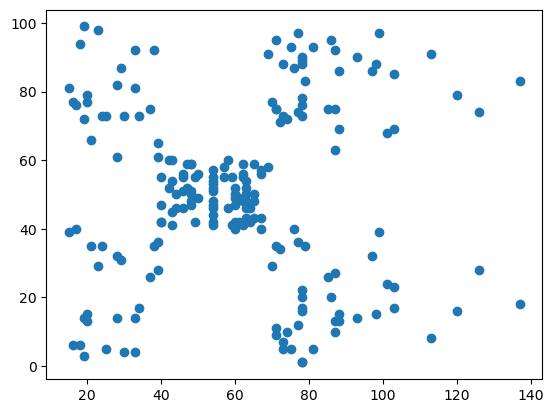

In [87]:
plt.scatter(col1,col2)

**WCSS : WITHIN CLUSTER SUM OF SQUARES**

**inertia**

In [91]:
from sklearn.cluster import KMeans

In [99]:
X=df.iloc[:,[3,4]]

In [101]:
kmeans=KMeans(n_clusters=1)

In [103]:
kmeans.fit(X)

KMeans(n_clusters=1)

In [115]:
kmeans.inertia_  # kmeans.inertia_ is the sum of squared distances of all data points from their nearest cluster centroid.

9352.192354283145

In [105]:
inertia=[]
for i in range(1,21):
    kmeans=KMeans(n_clusters=i)
    kmeans.fit(X)
    val=kmeans.inertia_
    inertia.append(val)
inertia
    

[269981.28,
 183714.08082173267,
 106348.37306211118,
 73880.64496247197,
 44448.45544793371,
 37564.94305477131,
 36696.48257257449,
 30579.86915445666,
 24491.300683020687,
 21321.464249108736,
 18115.04334590141,
 16972.587730829287,
 15213.279567493226,
 14551.885046056039,
 12378.29463256042,
 11769.99603721087,
 12013.044642857141,
 9800.471287994947,
 8786.402092352093,
 9352.192354283145]

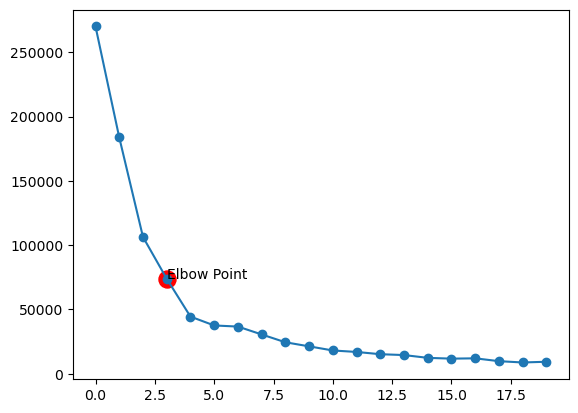

In [123]:
plt.plot(inertia,marker='o')
plt.scatter(3, inertia[3], color='red', s=150)
plt.text(3, inertia[3], "Elbow Point")
plt.show()